# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

nf-core/differentialabundance

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [3]:
import pandas as pd

df = pd.read_csv("data/salmon.merged.gene_counts.tsv", sep="\t")
print(df.head())
sample_map = {
    "Nac_oxy_1": "Sham_oxy_1",
    "Nac_oxy_2": "SNI_oxy_1",
    "Nac_oxy_3": "SNI_oxy_2",
    "Nac_oxy_4": "Sham_oxy_2",
    "Nac_oxy_5": "Sham_oxy_3",
    "Nac_oxy_6": "SNI_oxy_3",
    "Nac_oxy_7": "SNI_oxy_4",
    "Nac_oxy_8": "Sham_oxy_4",
    "Nac_Sal_1": "SNI_Sal_1",
    "Nac_Sal_2": "Sham_Sal_1",
    "Nac_Sal_3": "SNI_Sal_2",
    "Nac_Sal_4": "Sham_Sal_2",
    "Nac_Sal_5": "SNI_Sal_3",
    "Nac_Sal_6": "Sham_Sal_3",
    "Nac_Sal_7": "SNI_Sal_4",
    "Nac_Sal_8": "Sham_Sal_4",
}

              gene_id gene_name  Sham_oxy_1  Sham_oxy_2  Sham_oxy_3  \
0  ENSMUSG00000000001     Gnai3        69.0       294.0       259.0   
1  ENSMUSG00000000003      Pbsn         0.0         0.0         0.0   
2  ENSMUSG00000000028     Cdc45         1.0        10.0         2.0   
3  ENSMUSG00000000031       H19         0.0         0.0         0.0   
4  ENSMUSG00000000037     Scml2        12.0        21.0        12.0   

   Sham_oxy_4  Sham_Sal_1  Sham_Sal_2  Sham_Sal_3  Sham_Sal_4  SNI_oxy_1  \
0       444.0       242.0       651.0       622.0       406.0      383.0   
1         0.0         0.0         0.0         0.0         0.0        0.0   
2         6.0        15.0        15.0        22.0        12.0        9.0   
3         0.0         0.0         1.0         0.0         0.0        0.0   
4        18.0         9.0        24.0        36.0        19.0       18.0   

   SNI_oxy_2  SNI_oxy_3  SNI_oxy_4  SNI_Sal_1  SNI_Sal_2  SNI_Sal_3  SNI_Sal_4  
0      518.0      349.0      281.0 

In [2]:
lengths = pd.read_csv("data/rnaseq-out-small/star_salmon/salmon.merged.gene_lengths.tsv", sep="\t")
lengths = lengths.rename(columns=sample_map)
print(lengths.head())
count_samples = set(df.columns[1:])
length_samples = set(lengths.columns[1:])

lengths.to_csv("data/lengths.csv", index=False)

print("Missing from lengths:", count_samples - length_samples)
print("Extra in lengths:", length_samples - count_samples)

              gene_id gene_name   Sham_oxy_1    SNI_oxy_1    SNI_oxy_2  \
0  ENSMUSG00000000001     Gnai3  3124.407000  3107.183000  3067.475000   
1  ENSMUSG00000000003      Pbsn   630.321219   630.321219   630.321219   
2  ENSMUSG00000000028     Cdc45  1609.407000  1988.183000  1829.977092   
3  ENSMUSG00000000031       H19  1131.832093  1131.832093  1131.832093   
4  ENSMUSG00000000037     Scml2  3412.407000  4687.183000  4498.181260   

    Sham_oxy_2   Sham_oxy_3    SNI_oxy_3    SNI_oxy_4   Sham_oxy_4  \
0  3081.014000  3081.149000  3072.785000  3104.240000  3101.951000   
1   630.321219   630.321219   630.321219   630.321219   630.321219   
2  1962.014000  1962.149000  1557.785000  1985.240000  1586.951000   
3  1131.832093  1131.832093  1131.832093  1131.832093  1131.832093   
4  4661.014000  4661.149000  4652.785000  3756.754236  4060.722161   

     SNI_Sal_1   Sham_Sal_1    SNI_Sal_2   Sham_Sal_2    SNI_Sal_3  \
0  3096.872000  3111.209000  3091.812000  3072.957000  3122.0450

In [3]:
sample = []
condition = []
for col in df.columns[2:]:
    info = col.split("_")
    sample.append(col)
    condition.append("_".join(info[:2]))

samplesheet = {
    "sample": sample,
    "Condition": condition
}
samplesheet = pd.DataFrame(samplesheet)

print(samplesheet.head())

features = df[["gene_id","gene_name"]]
print(features.head())

df = df.drop('gene_name', axis=1)
print(df.head())

samplesheet.to_csv("data/samplesheet.csv", index=False)
features.to_csv("data/features.csv", index=False)
df.to_csv("data/matrix.csv", index=False)
    

       sample Condition
0  Sham_oxy_1  Sham_oxy
1  Sham_oxy_2  Sham_oxy
2  Sham_oxy_3  Sham_oxy
3  Sham_oxy_4  Sham_oxy
4  Sham_Sal_1  Sham_Sal
              gene_id gene_name
0  ENSMUSG00000000001     Gnai3
1  ENSMUSG00000000003      Pbsn
2  ENSMUSG00000000028     Cdc45
3  ENSMUSG00000000031       H19
4  ENSMUSG00000000037     Scml2
              gene_id  Sham_oxy_1  Sham_oxy_2  Sham_oxy_3  Sham_oxy_4  \
0  ENSMUSG00000000001        69.0       294.0       259.0       444.0   
1  ENSMUSG00000000003         0.0         0.0         0.0         0.0   
2  ENSMUSG00000000028         1.0        10.0         2.0         6.0   
3  ENSMUSG00000000031         0.0         0.0         0.0         0.0   
4  ENSMUSG00000000037        12.0        21.0        12.0        18.0   

   Sham_Sal_1  Sham_Sal_2  Sham_Sal_3  Sham_Sal_4  SNI_oxy_1  SNI_oxy_2  \
0       242.0       651.0       622.0       406.0      383.0      518.0   
1         0.0         0.0         0.0         0.0        0.0        0.0   


Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [4]:
!nextflow run nf-core/differentialabundance -profile rnaseq,docker -c nextflow.config -params-file params_diff_ab.yaml -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [dreamy_solvay] revision: 5cb5f9858f [master]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : data/samplesheet.csv
  contrasts                   : data/contrasts.csv
  outdir                      : results/diff_ab
  study_abundance_type        : counts
  seed                        : 42

[base] Abundance values
  matrix                      : data/matrix.csv
  f

The amount of DEGs is not coherent with the authors findings. To test if the heavy low-abundance-filtering could be the cause, the run is redone with no low-abundance filtering

In [6]:
!nextflow run nf-core/differentialabundance -profile rnaseq,docker -c nextflow.config -params-file params_diff_ab_no_filter.yaml -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [exotic_cori] revision: 5cb5f9858f [master]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : data/samplesheet.csv
  contrasts                   : data/contrasts.csv
  outdir                      : results/diff_ab_no_filter
  study_abundance_type        : counts
  seed                        : 42

[base] Abundance values
  matrix                      : data/matrix

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

input: data/samplesheet.csv
the samplesheet contains information columns like sample, condition

matrix: data/matrix.csv
in the matrix are the genes as rows and samples as columns. 

feature_length_matrix: data/lengths.csv
the length matrix contains the lengths per feature and sample for normalization

contrasts: data/contrasts.csv
contains the information on which groups to compare

features: data/features.csv
mapping of gene ids to gene names

seed: 42
Some supported methods have stochastic components. with a fixed seed you always get the same result

filtering_min_abundance: false
to stop discarding low and zero-abundance genes

outdir: results/diff_ab
resultsdirectory


What were the outputs of the pipeline?

In [5]:
#!TODO

Would you exclude any samples? If yes, which and why?

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

Without Filtering:
SNI-oxy vs. sham-sal: 1
Sham-oxy vs. sham-sal: 7
SNI-sal vs. sham-sal: 79

With Filtering:
SNI-oxy vs. sham-sal: 1
Sham-oxy vs. sham-sal: 7
SNI-sal vs. sham-sal: 79

Paper:
SNI-oxy vs. sham-sal: 1012
Sham-oxy vs. sham-sal: 2609
SNI-sal vs. sham-sal: 1457

The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

 nucleus accumbens (NAc)
 medial prefrontal cortex (mPFC)
 ventral tegmental area (VTA)

Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

Only a very small preselected class of drug-targets is shown.

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

The publication creates a Venn-Diagram out of these DEGs, to asses the contributions of the different parameters. Furthermore they are doing pathway analysis

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentioned.

In [4]:
sni_oxy = pd.read_csv("results/diff_ab/tables/differential/rnaseq/condition_altered_pain_state_study.deseq2.results_filtered.tsv", sep="\t")
sham_oxy = pd.read_csv("results/diff_ab/tables/differential/rnaseq/condition_oxy_Sham_study.deseq2.results_filtered.tsv", sep="\t")
sni_sal = pd.read_csv("results/diff_ab/tables/differential/rnaseq/condition_oxy_SNI_study.deseq2.results_filtered.tsv", sep="\t")

print(sni_oxy.sort_values(by="pvalue", ascending=True).head())
print(sham_oxy.sort_values(by="pvalue", ascending=True).head())
print(sni_sal.sort_values(by="pvalue", ascending=True).head())

              gene_id    baseMean  log2FoldChange     lfcSE        pvalue  \
0  ENSMUSG00000090546  267.483815       17.700441  2.734066  6.803362e-11   

           padj  
0  9.415853e-07  
              gene_id    baseMean  log2FoldChange     lfcSE        pvalue  \
4  ENSMUSG00000090546  267.483815       17.158700  2.845332  6.207417e-10   
1  ENSMUSG00000024256   13.160375        3.484335  1.375777  3.560712e-07   
3  ENSMUSG00000040452  109.632242        1.259840  0.432069  7.358150e-07   
0  ENSMUSG00000021609  101.036926        4.245578  2.468075  7.624569e-07   
6  ENSMUSG00000103497   62.530051        1.072646  0.372540  1.058177e-06   

       padj  
4  0.000010  
1  0.001951  
3  0.002089  
0  0.002089  
6  0.002485  
               gene_id       baseMean  log2FoldChange     lfcSE        pvalue  \
44  ENSMUSG00000090546     267.483815       27.503354  2.656934  1.514136e-25   
28  ENSMUSG00000074782      30.908873        4.060026  0.698975  2.857328e-09   
54  ENSMUSG00000097

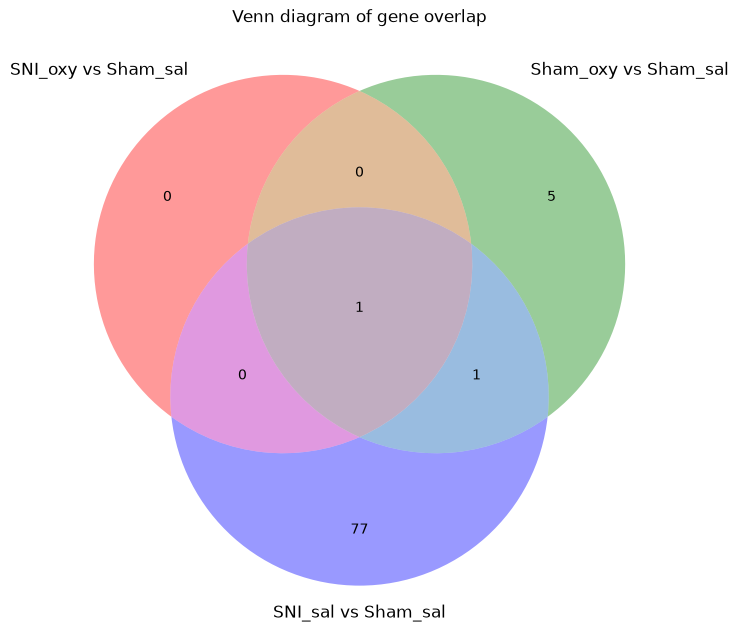

In [6]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted

set1 = set(sni_oxy["gene_id"])
set2 = set(sham_oxy["gene_id"])
set3 = set(sni_sal["gene_id"])

regions = {
    "100": len(set1 - set2 - set3),
    "010": len(set2 - set1 - set3),
    "001": len(set3 - set1 - set2),
    "110": len((set1 & set2) - set3),
    "101": len((set1 & set3) - set2),
    "011": len((set2 & set3) - set1),
    "111": len(set1 & set2 & set3),
}

dummy_regions = {region: 1 for region in regions}

plt.figure(figsize=(8, 8))

venn = venn3_unweighted(
    subsets=dummy_regions,
    set_labels=(
        "SNI_oxy vs Sham_sal",
        "Sham_oxy vs Sham_sal",
        "SNI_sal vs Sham_sal"
    )
)

for region_id, value in regions.items():
    label = venn.get_label_by_id(region_id)
    if label is not None:
        label.set_text(str(value))

plt.title("Venn diagram of gene overlap")
plt.savefig("venn.png")
plt.show()

The created Venn-Diagramm supports the idea, that oxycodon withdrawal induces some gene expression changes in pain-free mice that got oxy. 

In Mice with pain, these changes can not be observed, suggesting that the withdrawal symptomatic is counteracted by SNI. 

Mice with pain, but without oxy medicamentation show a clearly altered gene expression profile